In [1]:
pip install pandas numpy scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


Loading data...
Data shape: (291057, 140)
TARGET class distribution (0: No vo no, 1: vo no):
TARGET
0    267212
1     23845
Name: count, dtype: int64

Training...

=== MODEL EVALUATION RESULTS ===
Accuracy: 0.6893
ROC-AUC Score: 0.7508

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     53443
           1       0.16      0.68      0.26      4769

    accuracy                           0.69     58212
   macro avg       0.56      0.69      0.53     58212
weighted avg       0.90      0.69      0.76     58212



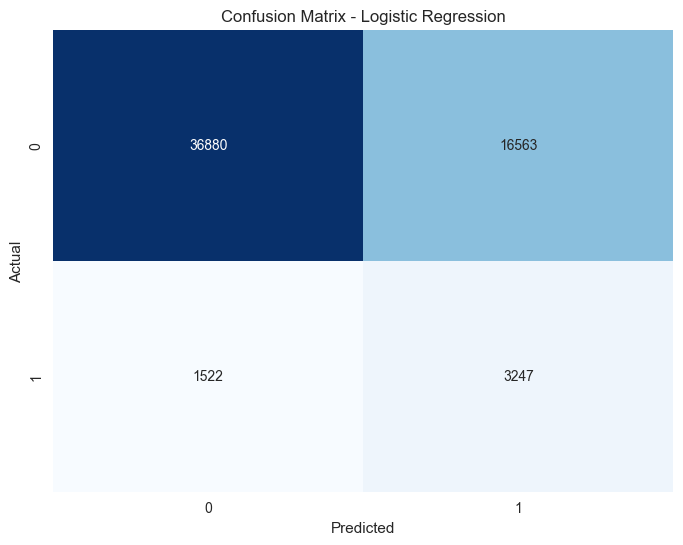

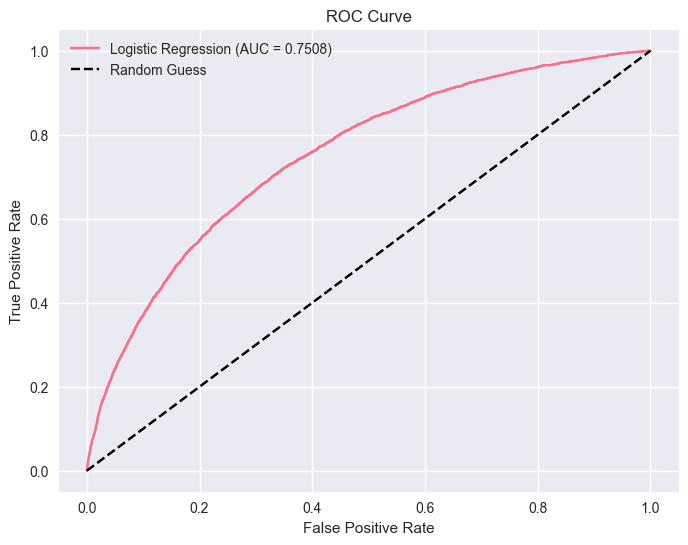

C:\Users\tungn\AppData\Local\Temp\ipykernel_18700\2223374371.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=top_features, palette='coolwarm')


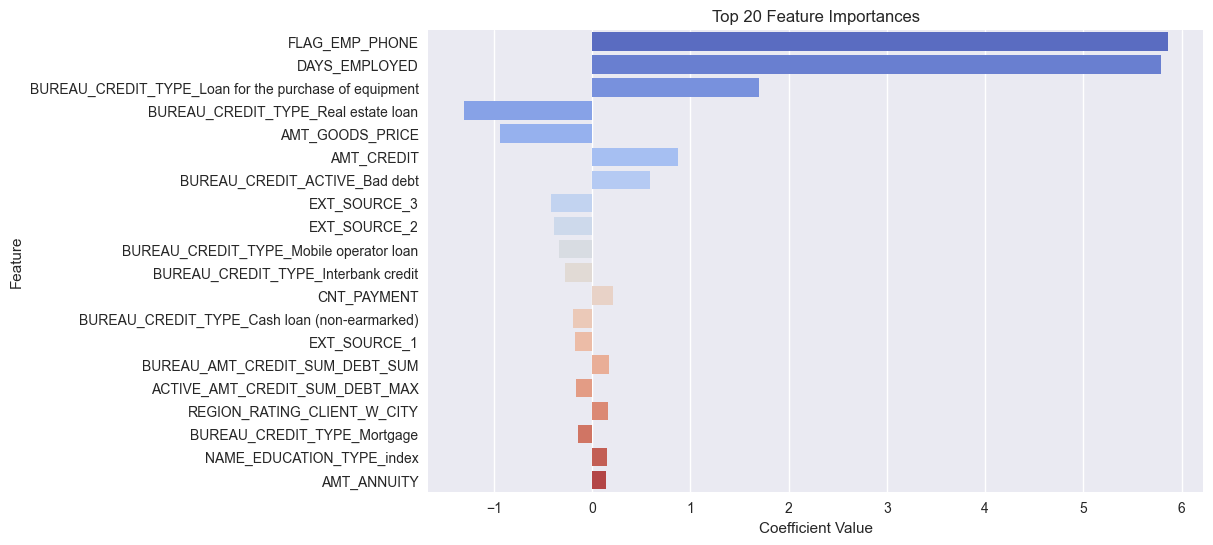

Done


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score

# Set up plotting style 
plt.style.use('seaborn-v0_8')  
sns.set_palette("husl")

# 1. LOAD AND CHECK DATA

file_path = r"C:\Users\tungn\Downloads\static_data (1).csv"  
print("Loading data...")
df = pd.read_csv(file_path)

print(f"Data shape: {df.shape}")
print("TARGET class distribution (0: No default, 1: Default):")
print(df['TARGET'].value_counts())

# 2. PREPROCESS DATA

X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

# Impute missing values with median
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# Split BEFORE scaling (to avoid data leakage)
# Tỷ lệ: 80% Train - 20% Test
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42, stratify=y)

# Scale AFTER split (fit on train, transform both)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. TRAIN LOGISTIC REGRESSION MODEL

print("\nTraining...")
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# 4. EVALUATE MODEL

y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print("\n=== MODEL EVALUATION RESULTS ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 5. VISUALIZATIONS
# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_pred_proba):.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

# Additional: Feature Importance (top 10)
coefficients = pd.DataFrame({
    'Feature': df.drop(columns=['TARGET', 'SK_ID_CURR']).columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)
plt.figure(figsize=(10, 6))
top_features = pd.concat([coefficients.head(10), coefficients.tail(10)])
top_features['Abs_Coefficient'] = top_features['Coefficient'].abs()
top_features = top_features.sort_values(by='Abs_Coefficient', ascending=False)
sns.barplot(x='Coefficient', y='Feature', data=top_features, palette='coolwarm')
plt.title('Top 20 Feature Importances')
plt.xlabel('Coefficient Value')
plt.grid(True, axis='x')
plt.show()

print("Done")